# Clustering of DGCD-129.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files


In [ ]:
#def action_delete_all_files(directory):
  '''
  Delete all files.
  '''
  try:
      # Check if the directory exists
      if os.path.exists(directory) and os.path.isdir(directory):
          # Iterate over all files and directories within the directory
          for filename in os.listdir(directory):
              file_path = os.path.join(directory, filename)

              # Check if it's a file and delete it
              if os.path.isfile(file_path) or os.path.islink(file_path):
                  os.remove(file_path)
                  print(f"Deleted file: {file_path}")
              # Check if it's a directory (optional) and skip or delete recursively
              elif os.path.isdir(file_path):
                  shutil.rmtree(file_path)  # Use this if you want to delete subdirectories
                  print(f"Deleted directory: {file_path}")
      else:
          print("Directory does not exist or is not a directory.")
  except Exception as e:
      print(f"Error while deleting files: {e}")

In [ ]:
#Checks if file is available if not then uploads it.
def check_for_file(file_name):
    # Define the file to be deleted
    file_namex = file_name

    # Path to the folder where the file is located
    content_folder_path = '/content/'
    file_path = os.path.join(content_folder_path, file_namex)

    # Check if the file exists
    if not os.path.isfile(file_path):
        # If the file does not exist, ask for upload
        print(f"File {file_path} does not exist. Upload {file_name} may be generated from last step")
        file_to_open = files.upload()
    else:
      print(f"{file_namex} Already uploaded.\n")

In [ ]:
# Path to the folder in Google Drive where the files are stored
drive_folder_path = '/content/'
#action_delete_all_files(drive_folder_path)

File /content/DGCD-129_using_node_txt.csv does not exist. Upload DGCD-129_using_node_txt.csv may be generated from last step


Saving DGCD-129_using_node_txt.csv to DGCD-129_using_node_txt.csv


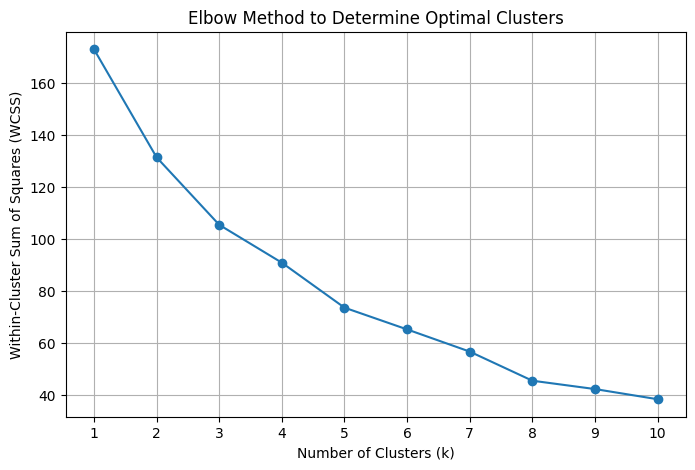

In [ ]:
# Load data
#file_path = "DGCD-129_using_graphml.csv"  # Replace with your file path
file_path = "DGCD-129_using_node_txt.csv"  # Replace with your file path

check_for_file(file_path)
#data = pd.read_excel(file_path, index_col=0)  # First column is used as the index
data = pd.read_csv(file_path, index_col=0)  # First column is used as the index

# Step 2: Convert the distance matrix to feature space using MDS
mds = MDS(n_components=3, dissimilarity="precomputed", random_state=42, metric=True)
features = mds.fit_transform(data.values)

# Step 3: Apply K-Means clustering and use the elbow method
wcss = []
max_clusters = 10  # Adjust this based on dataset size

for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# Step 4: Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters + 1), wcss, marker='o')
plt.title("Elbow Method to Determine Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(range(1, max_clusters + 1))
plt.grid()
plt.show()

In [ ]:
data.head()

,Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_network.txt,B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network,Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network,Grimm_Frau_Holle_clean_neu.txt_complete_network.txt,Bachmann_Arkadien_clean_neu.txt_complete_network.txt,Auerbach_Der_Kindesmord.txt_complete_network.txt,Storm_Im_Saal.txt_complete_network.txt,Hebel_Unverhofftes_Wiedersehen.txt_complete_network.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.txt,Dorn_Vorsicht_Steinschlag.txt_complete_network.txt,...,Franck_Streuselschnecke.txt_complete_network.txt,Mann_Beim_Propheten_clean.txt_complete_network.txt,Brecht_M��llers_nat��rliche_Haltung.txt_complete_net,Heym_Die_Sektion.txt_complete_network.txt,Bierbaum_Der_Mohr.txt_complete_network.txt,Heckmann_Das_Henkersmahl.txt_complete_network.txt,Grimm_Aschenputtel_clean.txt_complete_network.txt,Wendt_Tote_V��gel.txt_complete_network,Gr��n_Liebe.txt_complete_network,Kafka_Bericht_f��r_eine_Akademie_neu.txt_complete_network
Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_network.txt,0.000000,3.630861,2.771173,3.075846,1.807114,2.482597,2.783575,3.840979,2.612110,3.301263,...,4.435680,2.571627,2.867396,2.311682,2.007545,3.656599,2.360327,2.591461,3.902233,3.869748
B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network,3.630861,0.000000,3.609386,3.241960,3.132335,2.277110,2.012894,4.030478,3.159676,3.774895,...,4.712521,3.201988,2.279951,2.922582,2.840526,3.422324,2.904653,2.816226,2.990573,2.686002
Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network,2.771173,3.609386,0.000000,3.913844,2.332971,3.108513,2.980106,3.566216,3.280297,2.221782,...,3.720989,2.750990,3.461343,2.148263,2.349383,3.744247,2.666967,2.708910,4.098087,3.273813
Grimm_Frau_Holle_clean_neu.txt_complete_network.txt,3.075846,3.241960,3.913844,0.000000,2.961425,3.290812,3.115539,4.208123,4.116547,4.182266,...,5.436413,3.069242,3.257732,2.941183,2.996790,3.378309,3.014261,2.562341,3.983696,4.209127
Bachmann_Arkadien_clean_neu.txt_complete_network.txt,1.807114,3.132335,2.332971,2.961425,0.000000,2.686465,2.797427,3.574298,2.816209,2.741752,...,4.548622,2.279582,2.959137,2.065317,2.303961,3.085157,2.662606,2.482625,3.806643,3.751345


In [ ]:

# Step 5: Choose the optimal number of clusters (k) and fit K-Means
optimal_k = int(input("Enter the optimal number of clusters (k) based on the elbow plot: "))
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(features)

# Step 6: Analyze Results
print("Cluster Labels for Each Point:")
print(labels)

# Optional: Save results
data['Cluster'] = labels
"""
file_pathx="clustered_" + str(optimal_k) + "_" + file_path
data.to_excel(file_pathx)"""
file_pathx = "clustered_" + str(optimal_k) + "_" + file_path.replace(".csv", ".xlsx")
data.to_excel(file_pathx, index=False)


Enter the optimal number of clusters (k) based on the elbow plot: 8
Cluster Labels for Each Point:
[2 4 2 5 2 4 4 1 0 1 5 0 6 0 0 5 4 0 0 0 2 0 0 4 1 7 1 4 5 0 1 0 1 3 3]


In [ ]:
data["Cluster"]

,Cluster
Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_network.txt,2
B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network,4
Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network,2
Grimm_Frau_Holle_clean_neu.txt_complete_network.txt,5
Bachmann_Arkadien_clean_neu.txt_complete_network.txt,2
Auerbach_Der_Kindesmord.txt_complete_network.txt,4
Storm_Im_Saal.txt_complete_network.txt,4
Hebel_Unverhofftes_Wiedersehen.txt_complete_network.txt,1
Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.txt,0
Dorn_Vorsicht_Steinschlag.txt_complete_network.txt,1


#Silhouette Analysis in K-means Clustering

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Load data from Excel file
#file_path = "DGCD-129_using_graphml.csv"  # Replace with your file path
file_path = "DGCD-129_using_node_txt.csv"  # Replace with your file path


In [ ]:
df = pd.read_csv(file_path, index_col=0)

# Check the data
print(df.head())

                                                    Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_network.txt  \
Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_...                                           0.000000            
B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_com...                                           3.630861            
Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.t...                                           2.771173            
Grimm_Frau_Holle_clean_neu.txt_complete_network...                                           3.075846            
Bachmann_Arkadien_clean_neu.txt_complete_networ...                                           1.807114            

                                                    B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network  \
Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_...                                           3.630861              
B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_com...                                 

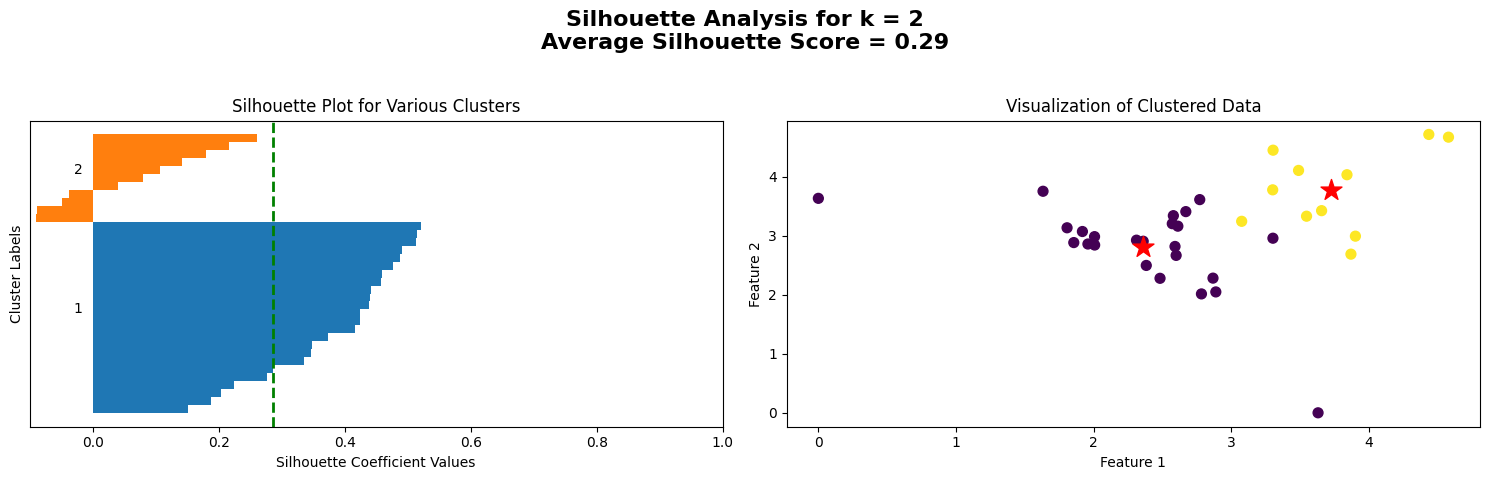

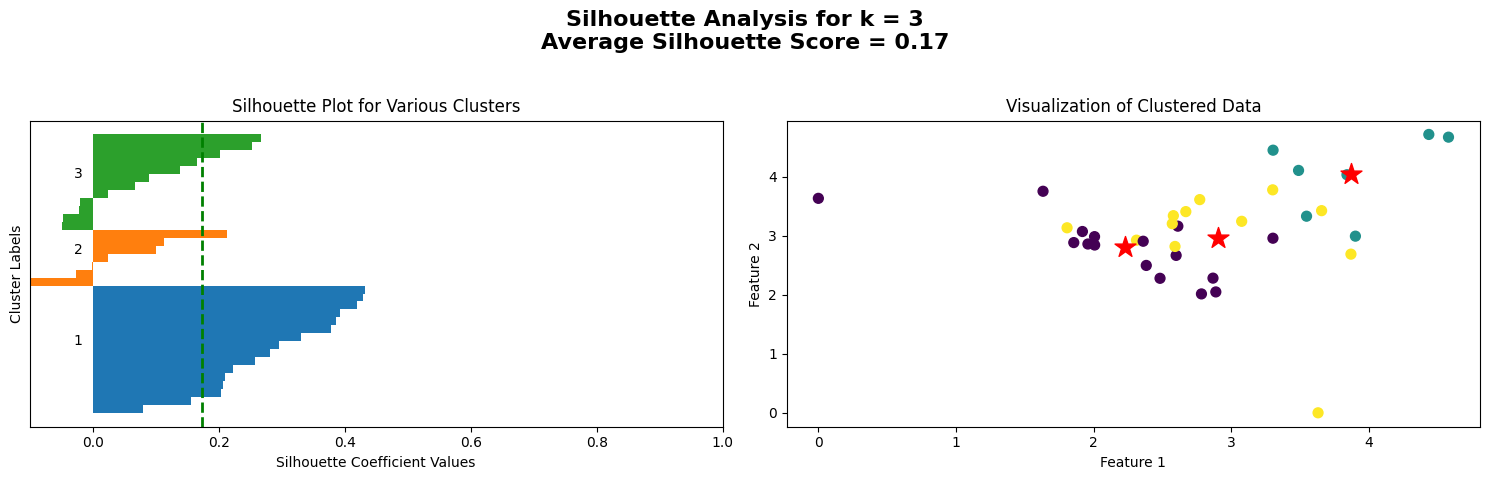

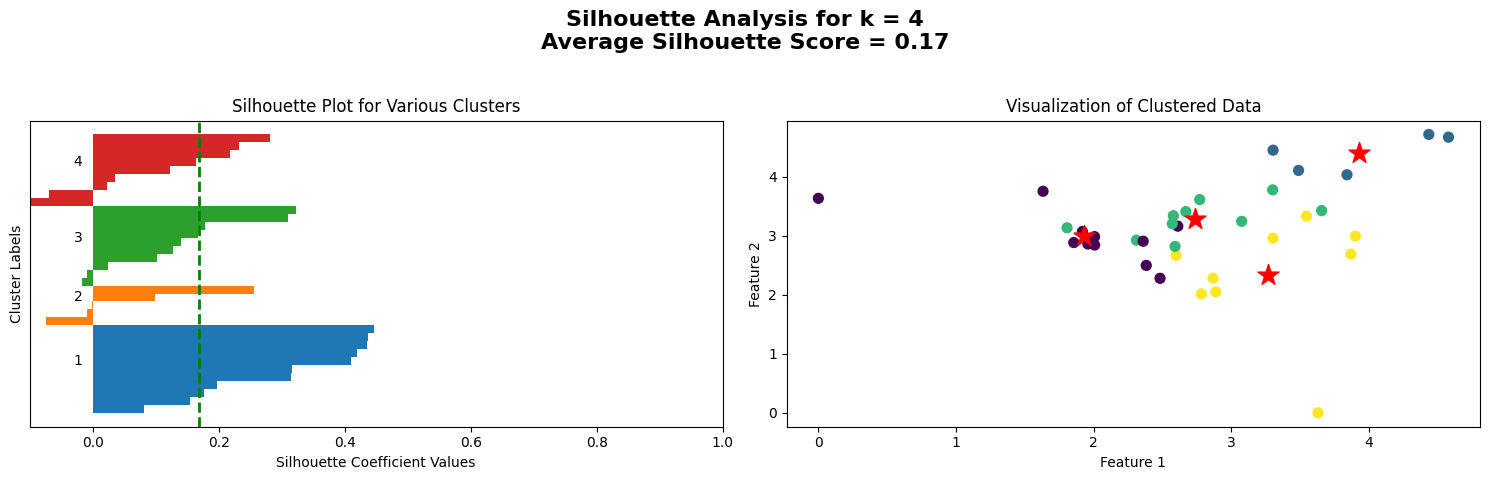

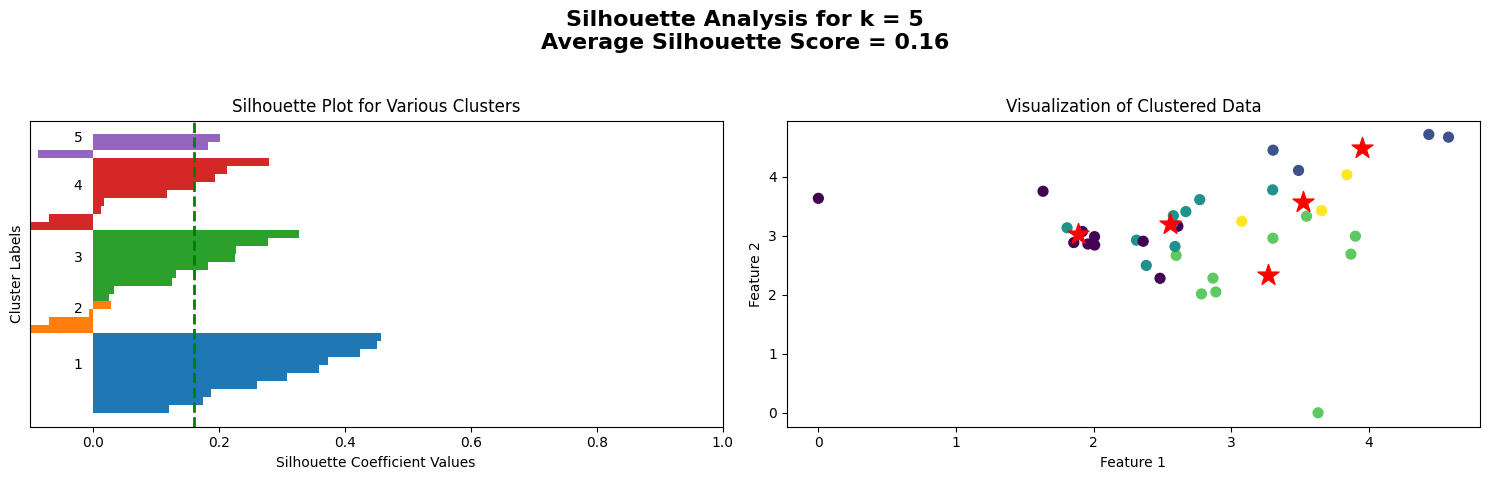

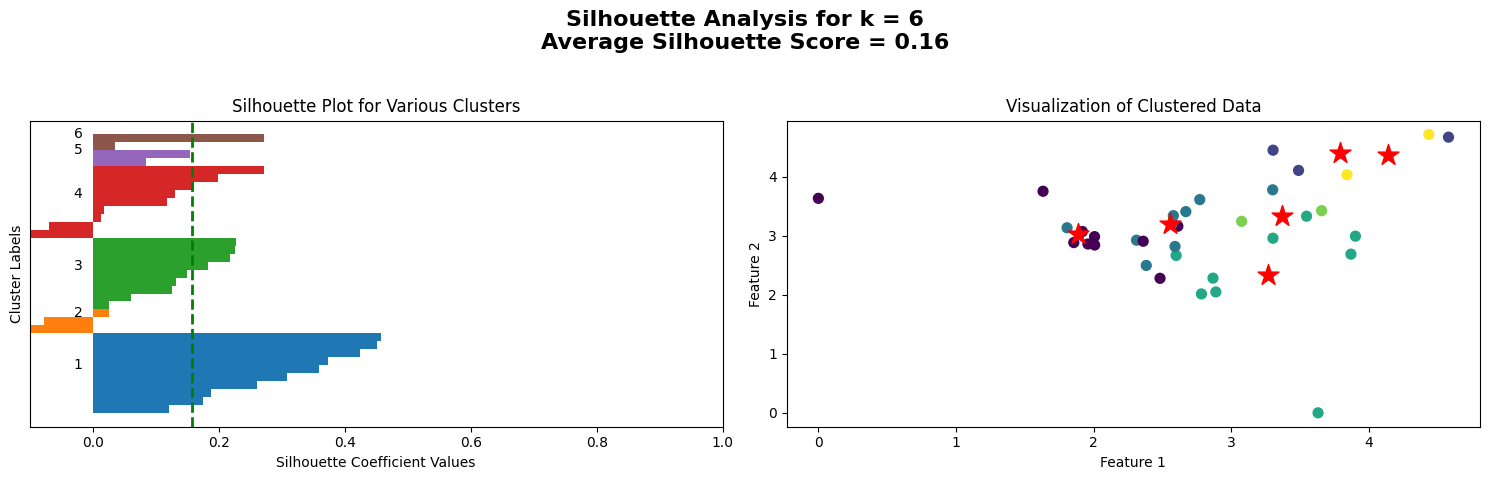

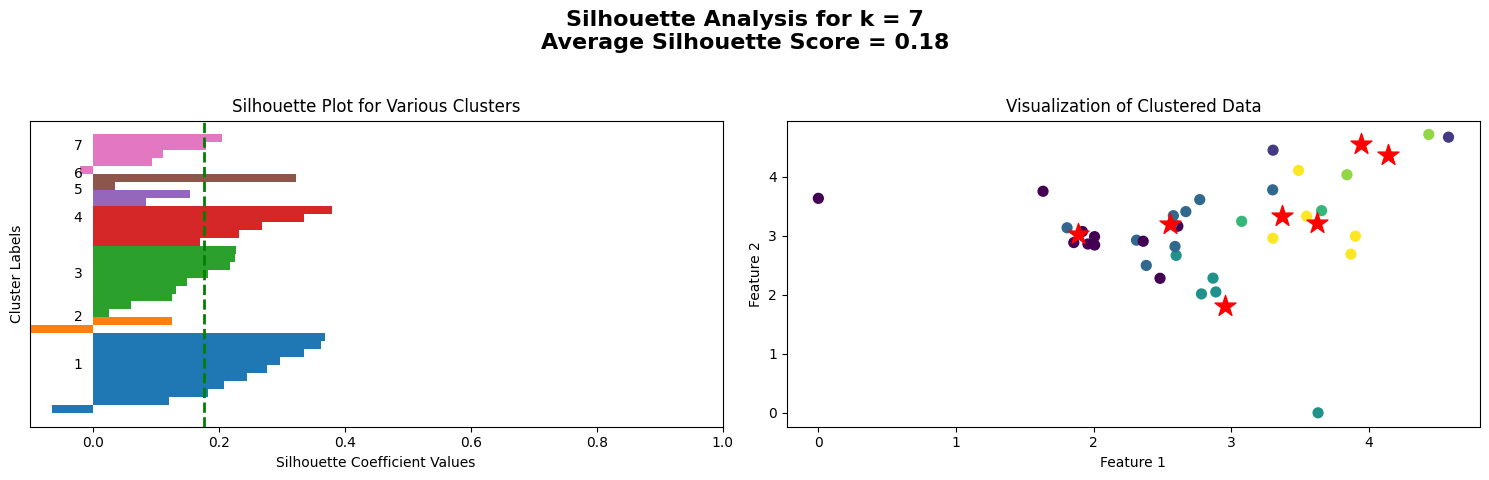

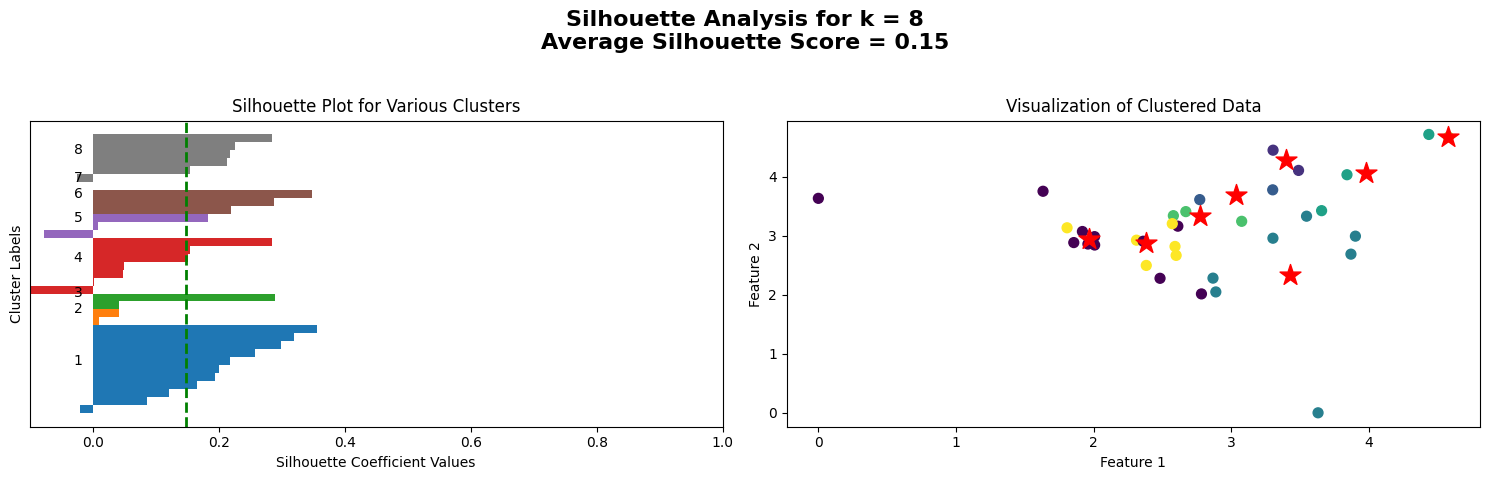

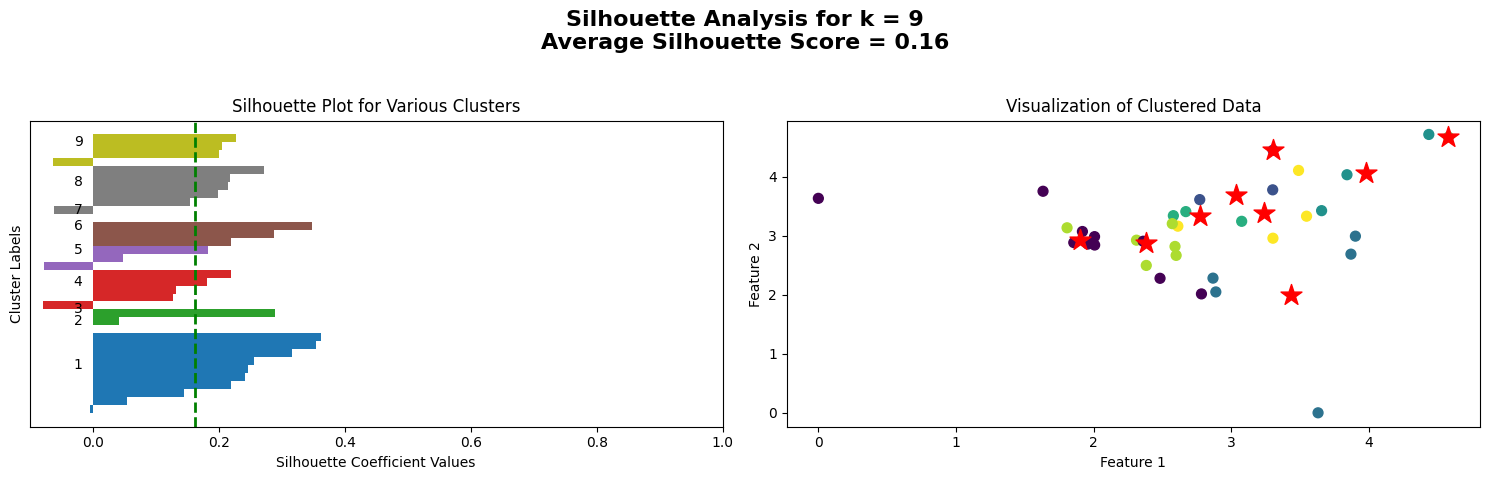

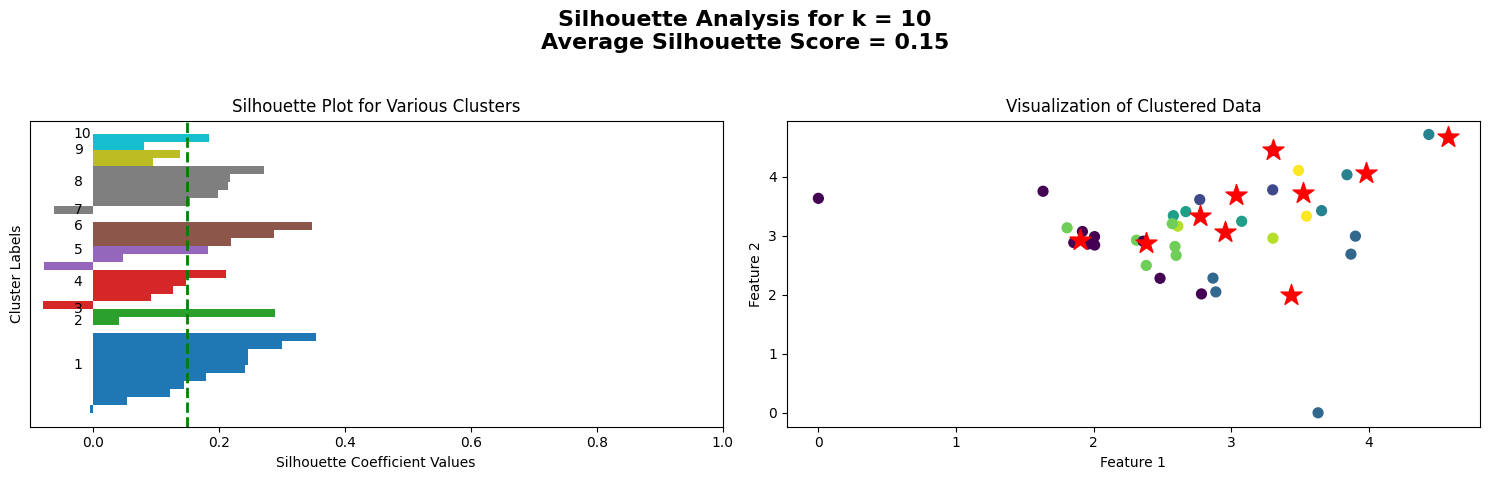

In [ ]:


# Use the matrix directly for clustering
data = df.values  # Convert DataFrame to numpy array

# Silhouette analysis for various numbers of clusters
for k in [2, 3, 4, 5 , 6 , 7 ,8 ,9, 10]:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Run the KMeans algorithm
    km = KMeans(n_clusters=k, random_state=42)
    y_predict = km.fit_predict(data)
    centroids = km.cluster_centers_

    # Calculate silhouette scores
    silhouette_vals = silhouette_samples(data, y_predict)
    avg_score = silhouette_score(data, y_predict)

    # Silhouette plot
    y_lower, y_upper = 0, 0
    for i, cluster in enumerate(np.unique(y_predict)):
        cluster_silhouette_vals = silhouette_vals[y_predict == cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        ax[0].barh(range(y_lower, y_upper), cluster_silhouette_vals, height=1)
        ax[0].text(-0.03, (y_lower + y_upper) / 2, str(i + 1))
        y_lower += len(cluster_silhouette_vals)

    ax[0].axvline(avg_score, linestyle='--', linewidth=2, color='green')
    ax[0].set_yticks([])
    ax[0].set_xlim([-0.1, 1])
    ax[0].set_xlabel('Silhouette Coefficient Values')
    ax[0].set_ylabel('Cluster Labels')
    ax[0].set_title('Silhouette Plot for Various Clusters')

    # Scatter plot of clustered data
    ax[1].scatter(data[:, 0], data[:, 1], c=y_predict, cmap='viridis', s=50)
    ax[1].scatter(centroids[:, 0], centroids[:, 1], marker='*', c='red', s=250)
    ax[1].set_xlabel('Feature 1')
    ax[1].set_ylabel('Feature 2')
    ax[1].set_title('Visualization of Clustered Data')

    # Add a super title for the entire figure
    plt.suptitle(f'Silhouette Analysis for k = {k}\nAverage Silhouette Score = {avg_score:.2f}',
                 fontsize=16, fontweight='semibold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for the suptitle
    plt.savefig(f'Silhouette_analysis_k{k}.jpg')
    plt.show()


# hierarchical clustering and Optimal Leaf Ordering

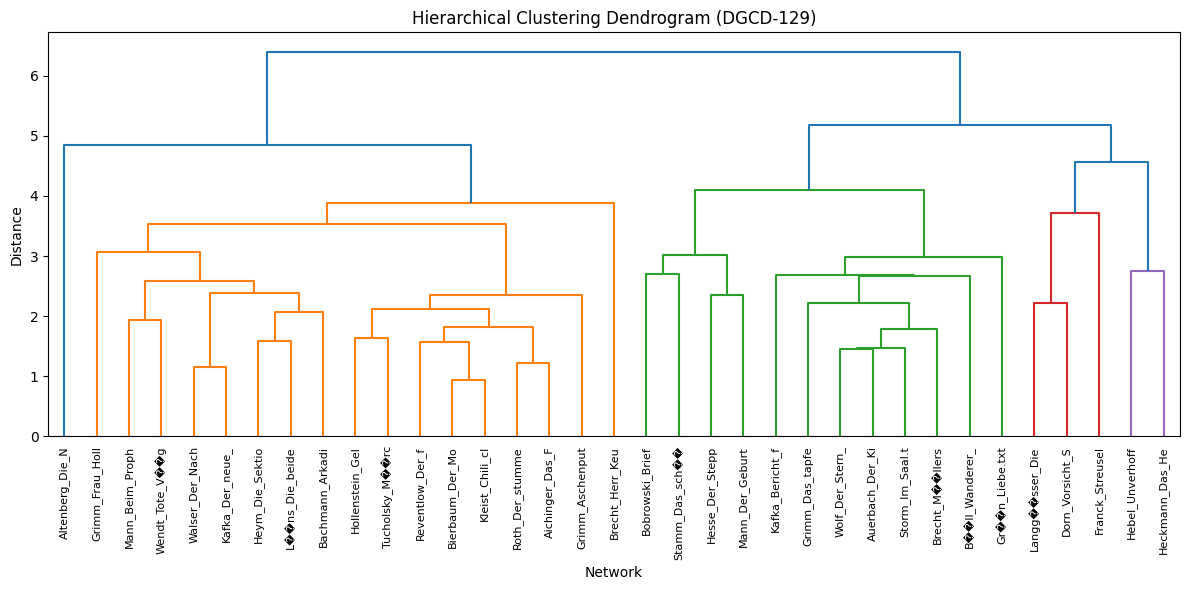

In [ ]:
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

data = pd.read_csv(file_path, index_col=0)  # First column is used as the index

labels = data.index.str[:15].tolist()

# Assume `dist_matrix` is your DGCD-129 distance matrix (numpy array or DataFrame)
dist_matrix = data.values
condensed_dist = squareform(dist_matrix)  # convert to condensed format

Z = linkage(condensed_dist, method='complete')  # average linkage for distances

Z_olo = optimal_leaf_ordering(Z, condensed_dist)  # reorder leaves

plt.figure(figsize=(12, 6))
dendrogram(Z_olo, labels=labels, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (DGCD-129)")
plt.xlabel("Network")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [ ]:
print(data.shape)  # Should be (n, n)


(35, 35)


In [ ]:
data

,Heckmann_Das_Henkersmahl.txt_complete_network.graphml,Bachmann_Arkadien_clean_neu.txt_complete_network.graphml,Altenberg_Die_Natur.txt_complete_network.graphml,Grimm_Das_tapfere_Schneiderlein.txt_complete_network.graphml,Stamm_Das_sch��nste_M��dchen.txt_complete_network,Mann_Beim_Propheten_clean.txt_complete_network.graphml,Kleist_Chili_clean_neu.txt_complete_network.graphml,Auerbach_Der_Kindesmord.txt_complete_network.graphml,Kafka_Bericht_f��r_eine_Akademie_neu.txt_complete_network.gra,Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network.gra,...,Reventlow_Der_feine_Dieb.txt_complete_network.graphml,Grimm_Frau_Holle_clean_neu.txt_complete_network.graphml,Wolf_Der_Stern_der_Sch��nheit.txt_complete_network.gra,Bobrowski_Brief_aus_Amerika.txt_complete_network.graphml,Storm_Im_Saal.txt_complete_network.graphml,Tucholsky_M��rchen.txt_complete_network.gra,Grimm_Aschenputtel_clean.txt_complete_network.graphml,Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.graphml,Heym_Die_Sektion.txt_complete_network.graphml,B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network.gra
Heckmann_Das_Henkersmahl.txt_complete_network.graphml,0.000000,0.183382,0.089468,0.312092,0.354361,0.775719,0.623829,0.666897,0.637148,0.627737,...,0.465491,0.171899,0.544776,0.200004,0.567357,0.105790,0.357529,0.564323,0.447525,0.448337
Bachmann_Arkadien_clean_neu.txt_complete_network.graphml,0.183382,0.000000,0.102244,0.164400,0.278361,0.665921,0.503337,0.547564,0.517195,0.509654,...,0.342351,0.057491,0.420988,0.095100,0.444344,0.079260,0.213133,0.440576,0.326291,0.330190
Altenberg_Die_Natur.txt_complete_network.graphml,0.089468,0.102244,0.000000,0.223665,0.293612,0.711029,0.545059,0.588783,0.558610,0.550447,...,0.386163,0.082477,0.464828,0.121458,0.488019,0.025739,0.270041,0.485576,0.369012,0.371565
Grimm_Das_tapfere_Schneiderlein.txt_complete_network.graphml,0.312092,0.164400,0.223665,0.000000,0.238350,0.573756,0.354707,0.398877,0.368339,0.368173,...,0.215071,0.142823,0.276822,0.153374,0.301689,0.214376,0.048975,0.305283,0.206646,0.219664
Stamm_Das_sch��nste_M��dchen.txt_complete_network,0.354361,0.278361,0.293612,0.238350,0.000000,0.545645,0.333831,0.371348,0.345867,0.320290,...,0.175334,0.254673,0.259381,0.187240,0.273149,0.293232,0.249619,0.257044,0.153675,0.139997
Mann_Beim_Propheten_clean.txt_complete_network.graphml,0.775719,0.665921,0.711029,0.573756,0.545645,0.000000,0.453664,0.456357,0.454412,0.448862,...,0.474887,0.656416,0.456530,0.622542,0.452300,0.705327,0.551750,0.450315,0.481826,0.483284
Kleist_Chili_clean_neu.txt_complete_network.graphml,0.623829,0.503337,0.545059,0.354707,0.333831,0.453664,0.000000,0.044442,0.013907,0.041882,...,0.173305,0.475961,0.084185,0.445216,0.065459,0.542361,0.314661,0.089080,0.194872,0.204557
Auerbach_Der_Kindesmord.txt_complete_network.graphml,0.666897,0.547564,0.588783,0.398877,0.371348,0.456357,0.044442,0.000000,0.030690,0.055599,...,0.215240,0.520174,0.127665,0.488726,0.106748,0.586313,0.358366,0.124271,0.236312,0.244308
Kafka_Bericht_f��r_eine_Akademie_neu.txt_complete_network.gra,0.637148,0.517195,0.558610,0.368339,0.345867,0.454412,0.013907,0.030690,0.000000,0.043165,...,0.186722,0.489689,0.097971,0.458916,0.078574,0.556033,0.328045,0.100285,0.208152,0.217370
Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network.gra,0.627737,0.509654,0.550447,0.368173,0.320290,0.448862,0.041882,0.055599,0.043165,0.000000,...,0.170192,0.483297,0.091499,0.446421,0.067044,0.547778,0.331449,0.075461,0.189862,0.195181


# agglomerative clustering

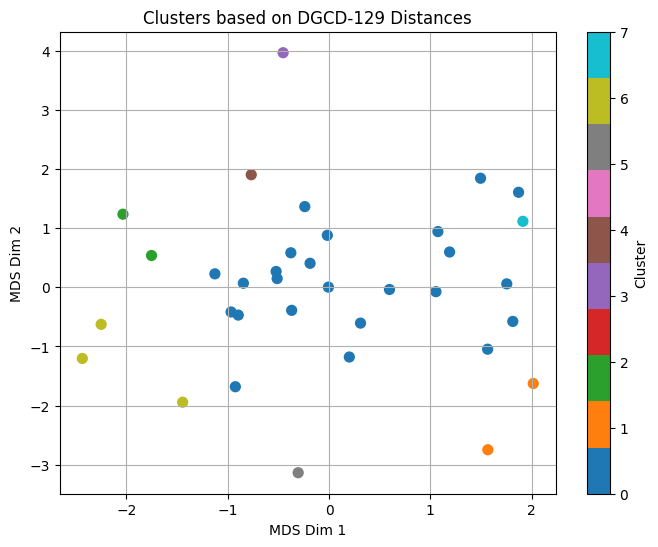

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=optimal_k, metric='precomputed', linkage='average')
labels = agg.fit_predict(data)

plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Clusters based on DGCD-129 Distances")
plt.xlabel("MDS Dim 1")
plt.ylabel("MDS Dim 2")
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
# Get names from the index
names = data.index

# Print each name with its assigned cluster
for name, label in zip(names, labels):
    print(f"{name} --> Cluster {label}")


Hollenstein_Gelb_wie_eine_Zitrone.txt_complete_network.txt --> Cluster 0
B��ll_Wanderer_kommst_du_nach_Spa_clean.txt_complete_network --> Cluster 0
Langg��sser_Die_Sippe_auf_dem_Berg_und_im_Tal.txt_complete_network --> Cluster 0
Grimm_Frau_Holle_clean_neu.txt_complete_network.txt --> Cluster 7
Bachmann_Arkadien_clean_neu.txt_complete_network.txt --> Cluster 0
Auerbach_Der_Kindesmord.txt_complete_network.txt --> Cluster 0
Storm_Im_Saal.txt_complete_network.txt --> Cluster 0
Hebel_Unverhofftes_Wiedersehen.txt_complete_network.txt --> Cluster 1
Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.txt --> Cluster 0
Dorn_Vorsicht_Steinschlag.txt_complete_network.txt --> Cluster 0
Walser_Der_Nachen.txt_complete_network.txt --> Cluster 0
Kleist_Chili_clean_neu.txt_complete_network.txt --> Cluster 0
Altenberg_Die_Natur.txt_complete_network.txt --> Cluster 3
Roth_Der_stumme_Prophet_Fragment_gb_clean_neu.txt_complete_network.txt --> Cluster 0
Stamm_Das_sch��nste_M��dchen.txt_complete_net --

In [ ]:
# Create a new DataFrame with names and cluster labels
results_df = pd.DataFrame({'Network': names, 'Cluster': labels})

# Save to Excel
results_df.to_excel("clustered_networks.xlsx", index=False)


# Neuer Abschnitt